# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 01 — Universe Construction

**Universe:** SEBI Large Cap + Mid Cap (AMFI classification, dynamically reconstituted every 6 months)
**Data Window:** Warm-up `2015-07-01` → `2018-06-30` (price history for factor lookback only) · Live universe from `2018-06-30` AMFI snapshot onward
**Data Source:** AMFI (universe classification) + yfinance (prices, volumes)

---

### What this notebook does differently from a "static universe" backtest

Most retail-style backtests pick **one** point-in-time list of Large/Mid cap stocks and freeze it for the
entire backtest. That is a methodological shortcut: a stock that grows from Mid Cap into Large Cap in 2022,
or a newly-listed IPO that becomes Mid Cap in 2024, would never enter the investable universe.

This notebook instead builds a **dynamic membership panel**: every AMFI snapshot from mid-2018 to the
present is downloaded and parsed, producing a stock-level history of `(snapshot_date, ticker, category)`.
Downstream notebooks use this panel to determine, **for each rebalance date independently**, exactly which
stocks were actually eligible for inclusion *at that point in time* — using only information that would
genuinely have been available then. No look-ahead.

```
Pipeline (this notebook)
────────────────────────
Step 1   AMFI catalogue (17 semi-annual snapshots, 2018-06-30 → latest)
Step 2   Download + parse every snapshot                → long-format membership panel
Step 3   Build master ticker universe (union across all snapshots)
Step 4   Universe evolution diagnostics (entries / exits per period)
Step 5   yfinance: NIFTY 50 benchmark
Step 6   yfinance: price + volume, master ticker list, full window
Step 7   Sanity filter (drop total download failures only — NOT coverage/liquidity)
Step 8   Simple + log daily returns
Step 9   Save all outputs to data/
```

### Why coverage / liquidity filtering is *not* done here

Because the universe is reconstituted dynamically, "does this stock have enough history / liquidity"
is a **point-in-time** question that can only be answered correctly at each individual rebalance date
(using a trailing window ending at that date). Applying a single global filter here — as a static-universe
notebook would — could incorrectly keep or drop a stock across periods where its eligibility genuinely
changed. That logic is therefore deferred to **Notebook 03 (Portfolio Construction)**, where it belongs.

### Methodological disclosures

> **Survivorship bias:** Each AMFI snapshot reflects classification as of that date. A stock delisted
> *between* two snapshots may still appear in the panel until the next snapshot drops it. This is a known,
> disclosed limitation — fully eliminating it would require daily classification data, which AMFI does not
> publish.

> **NSE only:** All tickers use the `.NS` suffix, taken directly from AMFI's "NSE Symbol" column. Companies
> listed only on BSE/MSEI (no NSE symbol) are excluded.

> **Symbol changes:** Some NSE symbols have been renamed over the study period (e.g. corporate actions,
> mergers). This notebook does not attempt historical symbol-mapping reconciliation; a handful of tickers
> may show as two distinct entries pre/post a rename. Disclosed as a limitation, revisited in Notebook 06.

> **First usable snapshot:** AMFI's site currently mislabels the "Jul–Dec 2017" Excel download (it points to
> the same file as "Jan–June 2018"). Rather than silently use corrupted data, this notebook starts the
> AMFI catalogue at the **2018-06-30** snapshot — the first one that is genuinely distinct and correct. This
> is why the walk-forward backtest (Notebook 04 onward) begins **July 2018**.

> **Warm-up length (2015-07-01, not 2017-07-01):** the factor model (locked in Notebook 02) includes Maximum
> Drawdown and Beta, each computed over a trailing **756-trading-day (~3-year)** window. To have a full
> 3-year lookback available right at the very first backtest rebalance (2018-07-01), price history must
> start **3 years earlier** — hence the warm-up now begins 2015-07-01 rather than 2017-07-01. This does not
> change `BACKTEST_START` or shrink the usable backtest window; it only pulls more historical price data.


### Cell 1 — Install Packages

In [1]:
!pip install yfinance pandas numpy matplotlib requests openpyxl scipy --quiet
print('Packages ready.')


Packages ready.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Cell 2 — Configuration & Dark Theme

Only two lines matter if you want to change the study window: `WARMUP_START` and `END_DATE`.
`BACKTEST_START` is fixed at `2018-07-01` because that is the first date at which a genuine AMFI
classification snapshot (2018-06-30) exists to define the live universe.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import requests
import warnings
import os
import time
import io
import glob
from datetime import datetime, date

warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  STUDY WINDOW  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
WARMUP_START    = '2015-07-01'   # price history start — sized for the longest factor lookback (756d
                                  # Max Drawdown / Beta in NB02, ~3yr), so it's available at BACKTEST_START
BACKTEST_START  = '2018-07-01'   # first live rebalance date (fixed — see Notebook overview)
END_DATE        = datetime.today().strftime('%Y-%m-%d')   # 'latest' — override to freeze a study window
# ══════════════════════════════════════════════════════════════════════════════

ANN_FACTOR         = 252     # trading days per year
RISK_FREE_RATE     = 0.0     # annualised, used from Notebook 05 onward (locked design decision)
DEFAULT_COST_BPS   = 20      # transaction cost default (sensitivity sweep: 0 / 10 / 20 / 50 bps in NB05)

# ── Visual style: dark theme used across ALL notebooks in this project ────────
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})

print('Configuration loaded.')
print(f'  Warm-up start     : {WARMUP_START}   (price history only, no live rebalancing)')
print(f'  Backtest start    : {BACKTEST_START} (first AMFI-defined live universe)')
print(f'  End date          : {END_DATE}')
print(f'  Trading days/yr   : {ANN_FACTOR}')
print(f'  Risk-free rate    : {RISK_FREE_RATE:.1%} (locked design assumption)')
print(f'  Default cost      : {DEFAULT_COST_BPS} bps per side (sweep in NB05)')


Configuration loaded.
  Warm-up start     : 2015-07-01   (price history only, no live rebalancing)
  Backtest start    : 2018-07-01 (first AMFI-defined live universe)
  End date          : 2026-07-16
  Trading days/yr   : 252
  Risk-free rate    : 0.0% (locked design assumption)
  Default cost      : 20 bps per side (sweep in NB05)


### Cell 3 — Directory Setup

In [3]:
# ── To persist data across Colab sessions, uncomment: ─────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_DIR = '/content/drive/MyDrive/Portfolio_Research'

BASE_DIR       = '.'
DATA_DIR       = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR     = os.path.join(BASE_DIR, 'output')
AMFI_RAW_DIR   = os.path.join(DATA_DIR, 'amfi_raw')   # manual-fallback files go here if download fails

os.makedirs(DATA_DIR,     exist_ok=True)
os.makedirs(OUTPUT_DIR,   exist_ok=True)
os.makedirs(AMFI_RAW_DIR, exist_ok=True)

print(f'data/           -> {os.path.abspath(DATA_DIR)}')
print(f'output/         -> {os.path.abspath(OUTPUT_DIR)}')
print(f'data/amfi_raw/  -> {os.path.abspath(AMFI_RAW_DIR)}  (manual-fallback AMFI files, if ever needed)')


data/           -> c:\Backup\Quant\Projects\Systematic portfolio reseearch\data
output/         -> c:\Backup\Quant\Projects\Systematic portfolio reseearch\output
data/amfi_raw/  -> c:\Backup\Quant\Projects\Systematic portfolio reseearch\data\amfi_raw  (manual-fallback AMFI files, if ever needed)


### Cell 4 — AMFI Snapshot Catalogue (2018-06-30 → latest)

Every entry is a `(snapshot_date, excel_url)` pair, taken directly from
[AMFI's categorisation page](https://www.amfiindia.com/otherdata/categorisation-of-stocks).
AMFI publishes a new classification every six months (Jan–Jun period -> 30-Jun snapshot;
Jul–Dec period -> 31-Dec snapshot). All 17 available snapshots from mid-2018 onward are listed —
**every one of these will be downloaded** to build the dynamic membership panel (unlike a
static-universe notebook, which would only need one).


In [4]:
AMFI_CATALOGUE = [
    # (snapshot_date, excel_url) — oldest first
    ('2018-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20listed%20companies%20during%20-Jan-June%202018.xlsx'),
    ('2018-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20listed%20companies%20during%20Jul-Dec%202018.xlsx'),
    ('2019-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20listed%20companies%20during%20-Jan-June%202019.xlsx'),
    ('2019-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20listed%20companies%20during%20Jul-Dec%202019.xlsx'),
    ('2020-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalization%20of%20Listed%20Companies%20during%20Jan%20-%20Jun%202020_Final.xlsx'),
    ('2020-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalization%20of%20Listed%20Companies%20during%20Jul%20-%20Dec%202020_Final.xlsx'),
    ('2021-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalization%20of%20List%20Companies%20during%20Jan-June%202021.xlsx'),
    ('2021-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalisation%20of%20Listed%20Companies%20during%20Jul%20-%20Dec%202021.xlsx'),
    ('2022-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalizationoflistedcompaniesduringthesixmonthsended30June2022.xlsx'),
    ('2022-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalizationoflistedcompaniesduringthesixmonthsended31Dec2022.xlsx'),
    ('2023-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalizationoflistedcompaniesduringthesixmonthsended30Jun2023.xlsx'),
    ('2023-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalizationoflistedcompaniesduringthesixmonthsended31Dec2023.xlsx'),
    ('2024-06-30', 'https://www.amfiindia.com/uploads/Average_Market_Capitalization_30_Jun2024_2a1ab4c1d8.xlsx'),
    ('2024-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalizationoflistedcompaniesduringthesixmonthsended31Dec2024.xlsx'),
    ('2025-06-30', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalization30Jun2025.xlsx'),
    ('2025-12-31', 'https://www.amfiindia.com/Themes/Theme1/downloads/AverageMarketCapitalization31Dec2025.xlsx'),
    ('2026-06-30', 'https://portal.amfiindia.com/spages/AverageMarketCapitalization30Jun2026.xlsx'),
]

# Keep only snapshots that have actually occurred by END_DATE
end_dt = datetime.strptime(END_DATE, '%Y-%m-%d').date()
AMFI_CATALOGUE_ACTIVE = [
    (snap, url) for snap, url in AMFI_CATALOGUE
    if datetime.strptime(snap, '%Y-%m-%d').date() <= end_dt
]

print(f'AMFI catalogue: {len(AMFI_CATALOGUE)} total snapshots defined, '
      f'{len(AMFI_CATALOGUE_ACTIVE)} active as of END_DATE={END_DATE}')
for snap, url in AMFI_CATALOGUE_ACTIVE:
    print(f'  {snap}   {url[:88]}...')


AMFI catalogue: 17 total snapshots defined, 17 active as of END_DATE=2026-07-16
  2018-06-30   https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20...
  2018-12-31   https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20...
  2019-06-30   https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20...
  2019-12-31   https://www.amfiindia.com/Themes/Theme1/downloads/Avg.%20Market%20Capitalization%20of%20...
  2020-06-30   https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalization%20of...
  2020-12-31   https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalization%20of...
  2021-06-30   https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalization%20of...
  2021-12-31   https://www.amfiindia.com/Themes/Theme1/downloads/Average%20Market%20Capitalisation%20of...
  2022-06-30   https://www.amfiindia.com/Themes/Theme1/downloads

### Cell 5 — AMFI Snapshot Loader

One robust loader function, reused for every snapshot in the catalogue. It:
1. Downloads the Excel file directly from AMFI.
2. Falls back to a manually-placed file in `data/amfi_raw/` if the download fails (AMFI's server
   occasionally rate-limits or renames files without notice).
3. Flexibly detects the relevant columns (AMFI has changed exact header wording across years),
   rather than hard-coding column positions.
4. Filters to Large Cap + Mid Cap only, keeps rows with a valid NSE symbol, appends `.NS`.


In [5]:
def _find_col(columns, must_contain):
    '''Case-insensitive substring match for a column name; returns first match or None.'''
    for c in columns:
        if must_contain.lower() in str(c).lower():
            return c
    return None


def load_amfi_snapshot(snapshot_date, url, amfi_raw_dir=None):
    '''
    Downloads + cleans one AMFI classification snapshot.

    Returns a DataFrame with columns:
        ['snapshot_date', 'ticker', 'company', 'isin', 'category']
    filtered to Large Cap / Mid Cap only, or None if unavailable.
    '''
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 Chrome/120.0 Safari/537.36'
        ),
    }

    raw = None
    try:
        resp = requests.get(url, headers=headers, timeout=30)
        if resp.status_code == 200 and len(resp.content) > 1000:
            raw = pd.read_excel(io.BytesIO(resp.content), header=1)
    except Exception:
        raw = None

    if raw is None and amfi_raw_dir is not None:
        # Manual fallback: place the file (any name) in data/amfi_raw/, named with the snapshot date,
        # e.g. data/amfi_raw/2022-06-30.xlsx
        candidate = os.path.join(amfi_raw_dir, f'{snapshot_date}.xlsx')
        if os.path.exists(candidate):
            raw = pd.read_excel(candidate, header=1)

    if raw is None:
        print(f'  [{snapshot_date}] FAILED — could not download or find local fallback.')
        print(f'      Manual fix: download from https://www.amfiindia.com/otherdata/categorisation-of-stocks')
        print(f'      and save as {os.path.join(amfi_raw_dir or "data/amfi_raw", snapshot_date)}.xlsx')
        return None

    raw.columns = [str(c).strip() for c in raw.columns]

    col_company = _find_col(raw.columns, 'Company name') or _find_col(raw.columns, 'Company Name')
    col_isin    = _find_col(raw.columns, 'ISIN')
    col_nse     = _find_col(raw.columns, 'NSE Symbol')
    col_cat     = _find_col(raw.columns, 'Categorization')

    if col_nse is None or col_cat is None:
        print(f'  [{snapshot_date}] FAILED — expected columns not found. Columns seen: {list(raw.columns)}')
        return None

    df = raw[[c for c in [col_company, col_isin, col_nse, col_cat] if c is not None]].copy()
    df.columns = [n for n, c in zip(['company', 'isin', 'nse_symbol', 'category'],
                                     [col_company, col_isin, col_nse, col_cat]) if c is not None]

    df['category'] = df['category'].astype(str).str.strip()
    df = df[df['category'].isin(['Large Cap', 'Mid Cap'])]

    df['nse_symbol'] = df['nse_symbol'].astype(str).str.strip()
    df = df[~df['nse_symbol'].isin(['-', '', 'nan', 'NaN'])]

    df['ticker']        = df['nse_symbol'] + '.NS'
    df['snapshot_date'] = snapshot_date

    out = df[['snapshot_date', 'ticker', 'company', 'isin', 'category']].drop_duplicates(subset='ticker')
    print(f'  [{snapshot_date}] OK — {len(out)} stocks '
          f'({(out.category == "Large Cap").sum()} Large / {(out.category == "Mid Cap").sum()} Mid)')
    return out


print('Loader function ready.')


Loader function ready.


### Cell 6 — Download & Assemble the Full Membership Panel

In [6]:
print(f'Downloading {len(AMFI_CATALOGUE_ACTIVE)} AMFI snapshots...')
print('=' * 60)

snapshot_frames = []
for snap, url in AMFI_CATALOGUE_ACTIVE:
    frame = load_amfi_snapshot(snap, url, amfi_raw_dir=AMFI_RAW_DIR)
    if frame is not None:
        snapshot_frames.append(frame)
    time.sleep(1.0)   # be polite to AMFI's server

print('=' * 60)

if not snapshot_frames:
    raise RuntimeError(
        'No AMFI snapshots could be downloaded. Check your internet connection, or manually '
        'place snapshot files in data/amfi_raw/ as described above, then re-run this cell.'
    )

membership_panel = pd.concat(snapshot_frames, ignore_index=True)
membership_panel['snapshot_date'] = pd.to_datetime(membership_panel['snapshot_date'])

print(f'Membership panel assembled: {len(membership_panel):,} rows '
      f'across {membership_panel.snapshot_date.nunique()} snapshots')
print(f'Unique tickers ever classified Large/Mid Cap: {membership_panel.ticker.nunique()}')


  [2018-06-30] OK — 247 stocks (99 Large / 148 Mid)
  [2018-12-31] OK — 247 stocks (99 Large / 148 Mid)
  [2019-06-30] OK — 247 stocks (99 Large / 148 Mid)
  [2019-12-31] OK — 247 stocks (99 Large / 148 Mid)
  [2020-06-30] OK — 247 stocks (98 Large / 149 Mid)
  [2020-12-31] OK — 247 stocks (98 Large / 149 Mid)
  [2021-06-30] OK — 247 stocks (99 Large / 148 Mid)
  [2021-12-31] OK — 247 stocks (99 Large / 148 Mid)
  [2022-06-30] OK — 247 stocks (99 Large / 148 Mid)
  [2022-12-31] OK — 247 stocks (99 Large / 148 Mid)
  [2023-06-30] OK — 247 stocks (99 Large / 148 Mid)
  [2023-12-31] OK — 248 stocks (100 Large / 148 Mid)
  [2024-06-30] OK — 249 stocks (100 Large / 149 Mid)
  [2024-12-31] OK — 249 stocks (100 Large / 149 Mid)
  [2025-06-30] OK — 248 stocks (100 Large / 148 Mid)
  [2025-12-31] OK — 248 stocks (100 Large / 148 Mid)
  [2026-06-30] OK — 248 stocks (100 Large / 148 Mid)
Membership panel assembled: 4,207 rows across 17 snapshots
Unique tickers ever classified Large/Mid Cap: 441


### Cell 8 — Master Ticker Universe & Membership Matrix

`MASTER_TICKERS` is the **union** of every stock that was ever Large or Mid Cap at any snapshot in the
study window (after applying the symbol-continuity map above) — this is the full download list for
yfinance. `membership_matrix` is a `tickers x snapshot_dates` pivot (`Large Cap` / `Mid Cap` / `NaN`)
used both as a downstream lookup (Notebook 03: "what was ticker X classified as, most recently, before
rebalance date D?") and for the universe-evolution diagnostic chart below.


In [7]:
MASTER_TICKERS = sorted(membership_panel['ticker'].unique().tolist())

amfi_name_map = (
    membership_panel.sort_values('snapshot_date')
    .drop_duplicates(subset='ticker', keep='last')
    .set_index('ticker')['company']
    .to_dict()
)

membership_matrix = membership_panel.pivot_table(
    index='ticker', columns='snapshot_date', values='category', aggfunc='first'
).sort_index(axis=1)

print(f'Master universe: {len(MASTER_TICKERS)} unique tickers (ever Large/Mid Cap, 2018-06-30 -> latest)')
print(f'Membership matrix shape: {membership_matrix.shape}  (tickers x snapshots)')


Master universe: 441 unique tickers (ever Large/Mid Cap, 2018-06-30 -> latest)
Membership matrix shape: (441, 17)  (tickers x snapshots)


### Cell 9 — Diagnostic: Universe Size & Composition Over Time

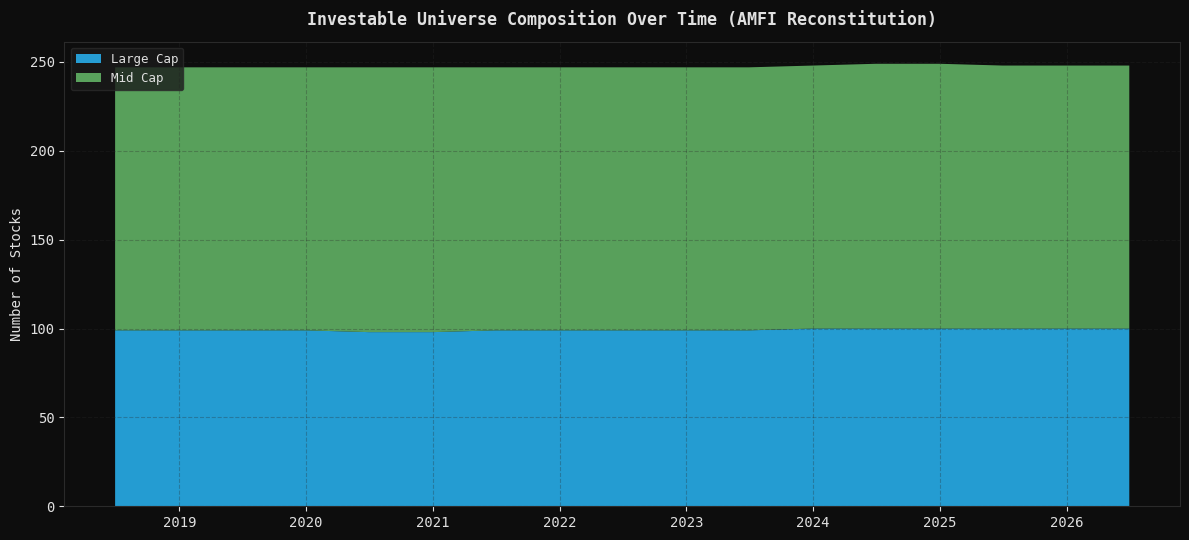

Saved -> .\output\01_universe_composition_over_time.png


In [8]:
snap_dates = membership_matrix.columns
n_large = [(membership_matrix[d] == 'Large Cap').sum() for d in snap_dates]
n_mid   = [(membership_matrix[d] == 'Mid Cap').sum()   for d in snap_dates]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(snap_dates, n_large, n_mid, colors=[COLORS[0], COLORS[2]],
             labels=['Large Cap', 'Mid Cap'], alpha=0.85)
ax.set_title('Investable Universe Composition Over Time (AMFI Reconstitution)',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Number of Stocks')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '01_universe_composition_over_time.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell 10 — Diagnostic: Universe Entries / Exits per Snapshot

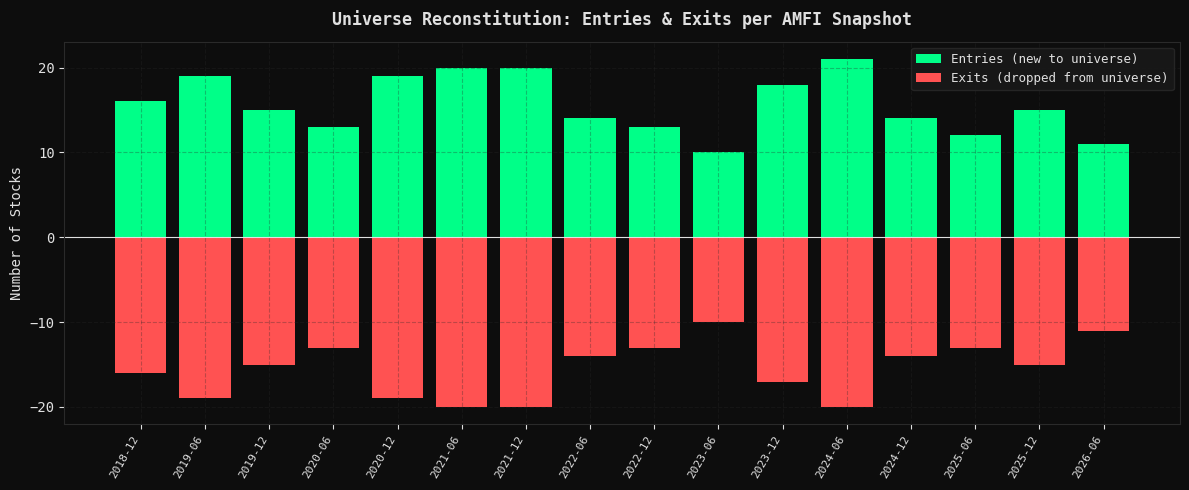

Saved -> .\output\01_universe_turnover.png
\nAverage entries per snapshot: 15.6
Average exits per snapshot:   15.6


In [9]:
entries, exits, labels = [], [], []
prev_set = None
for d in snap_dates:
    curr_set = set(membership_matrix.index[membership_matrix[d].notna()])
    if prev_set is not None:
        entries.append(len(curr_set - prev_set))
        exits.append(-len(prev_set - curr_set))
        labels.append(d.strftime('%Y-%m'))
    prev_set = curr_set

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(labels, entries, color=ACCENT,  label='Entries (new to universe)')
ax.bar(labels, exits,   color=ACCENT2, label='Exits (dropped from universe)')
ax.axhline(0, color=TEXT_COLOR, linewidth=0.8)
ax.set_title('Universe Reconstitution: Entries & Exits per AMFI Snapshot',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Number of Stocks')
plt.xticks(rotation=60, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '01_universe_turnover.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')
print(f'\\nAverage entries per snapshot: {np.mean(entries):.1f}')
print(f'Average exits per snapshot:   {np.mean([abs(e) for e in exits]):.1f}')


### Cell 11 — Benchmark: NIFTY 50

Primary benchmark, per project design. (Secondary benchmark — universe average return — is
computed in Notebook 05 directly from the constructed universe, since it isn't a market index.)


In [10]:
print(f'Downloading NIFTY 50 (^NSEI)  |  {WARMUP_START} -> {END_DATE}')

benchmark_raw = yf.download('^NSEI', start=WARMUP_START, end=END_DATE,
                             auto_adjust=True, progress=False)
benchmark = benchmark_raw['Close'].copy()
if isinstance(benchmark, pd.DataFrame):
    benchmark = benchmark.iloc[:, 0]
benchmark.name = 'NIFTY50'
benchmark = benchmark.dropna()

benchmark.to_csv(os.path.join(DATA_DIR, 'benchmark_nifty50.csv'), header=True)

bm_bt = benchmark[benchmark.index >= BACKTEST_START]
n_years   = (bm_bt.index[-1] - bm_bt.index[0]).days / 365.25
bm_cagr   = ((bm_bt.iloc[-1] / bm_bt.iloc[0]) ** (1 / n_years) - 1) * 100

print(f'  Trading days (full incl. warm-up) : {len(benchmark)}')
print(f'  Trading days (backtest window)    : {len(bm_bt)}')
print(f'  Backtest period                   : {bm_bt.index[0].date()} -> {bm_bt.index[-1].date()}')
print(f'  NIFTY 50 CAGR (backtest window)    : {bm_cagr:.2f}%')
print(f'  Saved -> data/benchmark_nifty50.csv')


  Trading days (full incl. warm-up) : 2718
  Trading days (backtest window)    : 1979
  Backtest period                   : 2018-07-02 -> 2026-07-15
  NIFTY 50 CAGR (backtest window)    : 10.68%
  Saved -> data/benchmark_nifty50.csv


### Cell 12 — Chart: NIFTY 50 Cumulative Return

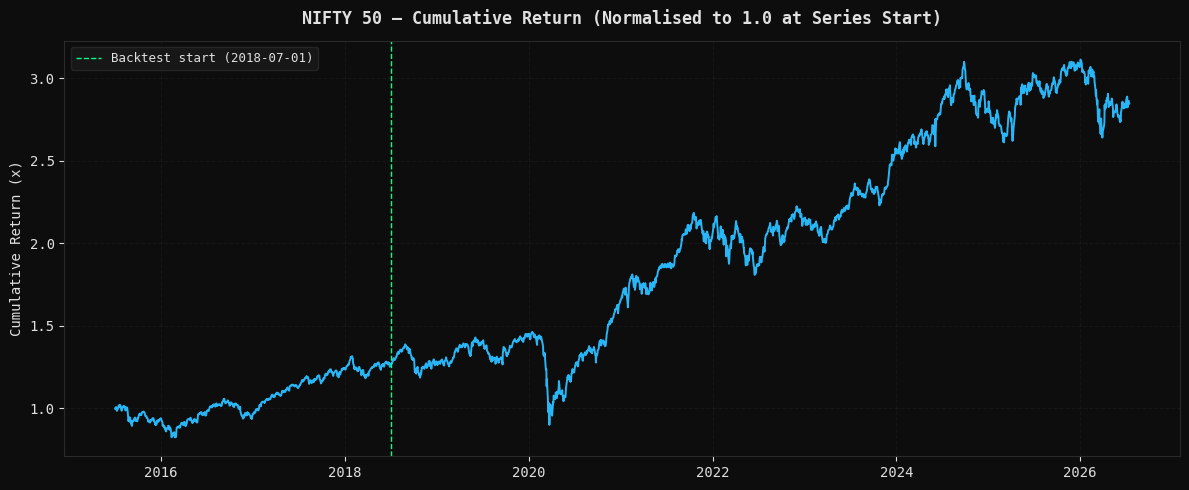

Saved -> .\output\01_benchmark_nifty50.png
Note: the 1.0 starting value is a mathematical normalisation of the cumulative-return
series, not an assumed investment amount.


In [11]:
bm_ret = benchmark.pct_change().dropna()
bm_cum = (1 + bm_ret).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bm_cum.index, bm_cum.values, color=COLORS[0], linewidth=1.4)
ax.axvline(pd.Timestamp(BACKTEST_START), color=ACCENT, linestyle='--', linewidth=1,
           label='Backtest start (2018-07-01)')
ax.set_title('NIFTY 50 — Cumulative Return (Normalised to 1.0 at Series Start)',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Cumulative Return (x)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '01_benchmark_nifty50.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')
print('Note: the 1.0 starting value is a mathematical normalisation of the cumulative-return')
print('series, not an assumed investment amount.')


### Cell 13 — Corporate Action Registry

Over an 8+ year window, a meaningful number of NSE symbols are renamed (corporate rebranding),
merged into an already-listed entity, or delisted outright. This registry is the **single source
of truth** for how each such ticker is treated downstream. Every entry is classified as exactly one
of four actions:

| Action | Meaning | What happens |
|---|---|---|
| `ticker_change` | Company still trades today, under a different NSE symbol | Re-downloaded under the new symbol, stored back under the original ticker |
| `merger` | Absorbed into another entity already present in the universe | Excluded — no separate stock to recover |
| `delisted` | Ceased trading (insolvency, buyout, voluntary delisting) | Excluded — no successor exists |
| `unknown` | Something happened (rename / demerger / restructuring), but not confirmed with enough confidence to auto-resolve | Attempted once under the original symbol; flagged for manual review either way |

**Scope, deliberately:** this is *not* an exhaustive NSE corporate-action database. It covers the
major cases relevant to this project's universe, each cross-checked against NSE circulars or
corporate announcements where possible. Transparency about what is and isn't resolved matters more
than completeness — see the Resolution Log and Data Quality Report later in this notebook for
exactly what fell into each bucket.


In [12]:
CORPORATE_ACTION_REGISTRY = {
    # ── Verified ticker changes (company still trades, new NSE symbol) ────────────
    'ADANITRANS' : {'action': 'ticker_change', 'new_ticker': 'ADANIENSOL',
                    'notes': 'Adani Transmission renamed Adani Energy Solutions, Aug-2023 (NSE circular)'},
    'AMARAJABAT' : {'action': 'ticker_change', 'new_ticker': 'ARE&M',
                    'notes': 'Amara Raja Batteries renamed Amara Raja Energy & Mobility, Oct-2023 (NSE circular)'},
    'BAJAJAUTO'  : {'action': 'ticker_change', 'new_ticker': 'BAJAJ-AUTO',
                    'notes': 'Ticker formatting only — AMFI file omits the hyphen'},
    'CADILAHC'   : {'action': 'ticker_change', 'new_ticker': 'ZYDUSLIFE',
                    'notes': 'Cadila Healthcare renamed Zydus Lifesciences, 2022'},
    'IDFCBANK'   : {'action': 'ticker_change', 'new_ticker': 'IDFCFIRSTB',
                    'notes': 'Renamed IDFC First Bank post Capital First merger'},
    'MOTHERSUMI' : {'action': 'ticker_change', 'new_ticker': 'MOTHERSON',
                    'notes': 'Motherson Sumi renamed Samvardhana Motherson, 2022'},
    'NIITTECH'   : {'action': 'ticker_change', 'new_ticker': 'COFORGE',
                    'notes': 'NIIT Technologies renamed Coforge, 2020'},
    'TATAGLOBAL' : {'action': 'ticker_change', 'new_ticker': 'TATACONSUM',
                    'notes': 'Tata Global Beverages renamed Tata Consumer Products, 2020'},
    'ZOMATO'     : {'action': 'ticker_change', 'new_ticker': 'ETERNAL',
                    'notes': 'Zomato renamed Eternal, 2024'},
    'PVR'        : {'action': 'ticker_change', 'new_ticker': 'PVRINOX',
                    'notes': 'PVR-INOX merger, surviving listed entity, 2023'},
    'GUJFLUORO'  : {'action': 'ticker_change', 'new_ticker': 'FLUOROCHEM',
                    'notes': 'Gujarat Fluorochemicals ticker rename'},
    'INFRATEL'   : {'action': 'ticker_change', 'new_ticker': 'INDUSTOWER',
                    'notes': 'Bharti Infratel merged into Indus Towers, surviving ticker, 2020'},
    'IIFLWAM'    : {'action': 'ticker_change', 'new_ticker': '360ONE',
                    'notes': 'IIFL Wealth Management renamed 360 ONE WAM, 2023'},
    'RUCHI'      : {'action': 'ticker_change', 'new_ticker': 'PATANJALI',
                    'notes': 'Ruchi Soya renamed Patanjali Foods, 2022'},
    'RNAM'       : {'action': 'ticker_change', 'new_ticker': 'NAM-INDIA',
                    'notes': 'Reliance Nippon Life AMC renamed Nippon Life India AMC'},
    'NAMINDIA'   : {'action': 'ticker_change', 'new_ticker': 'NAM-INDIA',
                    'notes': 'Duplicate AMFI entry, same target as RNAM'},
    'SHRIRAMCIT' : {'action': 'ticker_change', 'new_ticker': 'SHRIRAMFIN',
                    'notes': 'Shriram City Union Finance merged into Shriram Finance, 2022'},
    'SRTRANSFIN' : {'action': 'ticker_change', 'new_ticker': 'SHRIRAMFIN',
                    'notes': 'Shriram Transport Finance merged into Shriram Finance, 2022'},
    'MCDOWELLN'  : {'action': 'ticker_change', 'new_ticker': 'MCDOWELL-N',
                    'notes': 'Ticker formatting duplicate (United Spirits)'},

    # ── Mergers: absorbed into an entity already present in the universe ───────────
    'ALBK'       : {'action': 'merger', 'notes': 'Merged into Indian Bank (2020)'},
    'BHARATFIN'  : {'action': 'merger', 'notes': 'Merged into IndusInd Bank (2019)'},
    'CORPBANK'   : {'action': 'merger', 'notes': 'Merged into Union Bank of India (2020)'},
    'GSKCONS'    : {'action': 'merger', 'notes': 'Merged into Hindustan Unilever (2020)'},
    'GRUH'       : {'action': 'merger', 'notes': 'Merged into Bandhan Bank (2019)'},
    'HDFC'       : {'action': 'merger', 'notes': 'Merged into HDFC Bank (2023)'},
    'ISEC'       : {'action': 'merger', 'notes': 'Merged into ICICI Bank (2024)'},
    'MINDTREE'   : {'action': 'merger', 'notes': 'Merged into LTIMindtree, surviving ticker LTIM (2022)'},
    'LTI'        : {'action': 'merger', 'notes': 'Merged into LTIMindtree, surviving ticker LTIM (2022)'},
    'ORIENTBANK' : {'action': 'merger', 'notes': 'Merged into Punjab National Bank (2020)'},

    # ── Delisted: ceased trading, no successor ──────────────────────────────────────
    'DHFL'       : {'action': 'delisted', 'notes': 'Insolvency proceedings, delisted (2021)'},
    'SUVENPHAR'  : {'action': 'delisted', 'notes': 'Delisted post-merger with Cohance Lifesciences (2023)'},
    'WABCOINDIA' : {'action': 'delisted', 'notes': 'Acquired & delisted by ZF CV Control Systems (2020)'},
    'AKZOINDIA'  : {'action': 'delisted', 'notes': 'Voluntary delisting from NSE/BSE (2022)'},

    # ── Unknown: a corporate action is known to have occurred, but not confirmed
    #    with enough confidence to auto-resolve a successor ticker ──────────────────
    'ADANIGAS'    : {'action': 'unknown', 'notes': 'Possible symbol change around Adani Total Gas listing; successor not independently verified'},
    'GMRINFRA'    : {'action': 'unknown', 'notes': 'Demerger of airports business (~2024); successor ticker not independently verified'},
    'JUBILANT'    : {'action': 'unknown', 'notes': 'Demerged into Jubilant Pharmova / Jubilant Ingrevia; not a 1:1 rename'},
    'CENTURYTEX'  : {'action': 'unknown', 'notes': 'Demerged into multiple Aditya Birla Group entities; not a 1:1 rename'},
    'L&TFH'       : {'action': 'unknown', 'notes': 'Possible restructuring/rename; successor not independently verified'},
    'IBULHSGFIN'  : {'action': 'unknown', 'notes': 'Possible rename to Sammaan Capital; not independently verified with high confidence'},
}

print(f'Corporate Action Registry loaded: {len(CORPORATE_ACTION_REGISTRY)} entries')
_action_counts = pd.Series([v['action'] for v in CORPORATE_ACTION_REGISTRY.values()]).value_counts()
for action, n in _action_counts.items():
    print(f'  {action:14s}: {n}')


Corporate Action Registry loaded: 39 entries
  ticker_change : 19
  merger        : 10
  unknown       : 6
  delisted      : 4


### Cell 14 — Download Plan: Apply the Registry Before Downloading

Pipeline for every ticker in the master universe:

```
AMFI ticker  ->  Corporate Action Registry  ->  Resolved ticker (if applicable)  ->  Download  ->  Record status
```

- `merger` / `delisted` tickers are **not** attempted at all — we already know why they'd fail, so
  there's no reason to spend an API call confirming it.
- `ticker_change` tickers are downloaded under their **resolved** symbol.
- `unknown` and not-in-registry tickers are downloaded under their **original** symbol (we don't have
  a confirmed alternative).


In [13]:
def resolve_ticker(ticker):
    '''
    Looks up a MASTER_TICKERS entry (with .NS suffix) against the Corporate Action Registry.
    Returns (registry_action, download_symbol, notes):
        registry_action : one of 'ticker_change' / 'merger' / 'delisted' / 'unknown' / None (not in registry)
        download_symbol : the .NS symbol to actually attempt downloading (None if pre-excluded)
        notes           : registry notes, or '' if not in registry
    '''
    base = ticker[:-3] if ticker.endswith('.NS') else ticker   # strip '.NS'
    entry = CORPORATE_ACTION_REGISTRY.get(base)

    if entry is None:
        return None, ticker, ''

    action = entry['action']
    notes  = entry.get('notes', '')

    if action == 'ticker_change':
        return action, entry['new_ticker'] + '.NS', notes
    elif action in ('merger', 'delisted'):
        return action, None, notes
    else:   # 'unknown'
        return action, ticker, notes   # attempt under original symbol


download_plan = []
for t in MASTER_TICKERS:
    action, download_symbol, notes = resolve_ticker(t)
    download_plan.append({
        'ticker': t, 'registry_action': action,
        'download_symbol': download_symbol, 'registry_notes': notes,
    })
download_plan_df = pd.DataFrame(download_plan).set_index('ticker')

pre_excluded = download_plan_df[download_plan_df['download_symbol'].isna()]
to_attempt   = download_plan_df[download_plan_df['download_symbol'].notna()]

print(f'Master universe           : {len(download_plan_df)} tickers')
print(f'Pre-excluded (merger/delisted, registry-confirmed, no download attempted): {len(pre_excluded)}')
print(f'To attempt (original, renamed, or unknown)                              : {len(to_attempt)}')

# De-duplicate download symbols (e.g. RNAM & NAMINDIA both resolve to NAM-INDIA.NS)
unique_download_symbols = sorted(to_attempt['download_symbol'].unique().tolist())
print(f'Unique symbols to actually fetch from yfinance                          : {len(unique_download_symbols)}')


Master universe           : 441 tickers
Pre-excluded (merger/delisted, registry-confirmed, no download attempted): 14
To attempt (original, renamed, or unknown)                              : 427
Unique symbols to actually fetch from yfinance                          : 410


### Cell 15 — Download Price & Volume (Registry-Resolved Symbols)

`auto_adjust=True` returns Adjusted Close (dividends/splits corrected). Batches of 20 symbols with a
pause between batches; anything that fails the batch pass is retried individually (recovers
transient Yahoo Finance rate-limit / timezone-lookup hiccups, which are common and unrelated to
actual data availability).


In [14]:
def _split_close_volume(raw, batch):
    '''
    Robustly splits a yf.download(group_by='ticker') result into (Close, Volume) frames,
    regardless of whether the result is a MultiIndex (multi-symbol) or a flat Index
    (single-symbol, or some yfinance versions even for >1 symbol). Handles both shapes
    explicitly rather than guessing from len(batch).
    '''
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = set(raw.columns.get_level_values(0))
        level1 = set(raw.columns.get_level_values(1))
        if 'Close' in level1:
            c = raw.xs('Close',  axis=1, level=1)
            v = raw.xs('Volume', axis=1, level=1)
        elif 'Close' in level0:
            c = raw.xs('Close',  axis=1, level=0)
            v = raw.xs('Volume', axis=1, level=0)
        else:
            raise ValueError(f'Unrecognised MultiIndex structure: {raw.columns[:4].tolist()}')
    else:
        if 'Close' not in raw.columns:
            raise ValueError(f"'Close' not in columns: {list(raw.columns)}")
        c = raw[['Close']].rename(columns={'Close': batch[0]})
        v = raw[['Volume']].rename(columns={'Volume': batch[0]})
    return c, v


def batch_download(symbols, start, end, batch_size=20, pause=2.0):
    '''Downloads adjusted Close and Volume for all symbols in batches. Returns (prices, volumes, failed).'''
    all_close, all_vol, failed = [], [], []
    batches = [symbols[i:i + batch_size] for i in range(0, len(symbols), batch_size)]

    for i, batch in enumerate(batches):
        print(f'  Batch {i+1:02d}/{len(batches)}  ({len(batch)} symbols)... ', end='')
        try:
            raw = yf.download(batch, start=start, end=end,
                               auto_adjust=True, progress=False, group_by='ticker')
            c, v = _split_close_volume(raw, batch)
            all_close.append(c)
            all_vol.append(v)
            print('OK')
        except Exception as e:
            print(f'ERROR: {e}')
            failed.extend(batch)
        if i < len(batches) - 1:
            time.sleep(pause)

    prices  = pd.concat(all_close, axis=1) if all_close else pd.DataFrame()
    volumes = pd.concat(all_vol, axis=1)   if all_vol   else pd.DataFrame()
    prices  = prices.loc[:, ~prices.columns.duplicated()]
    volumes = volumes.loc[:, ~volumes.columns.duplicated()]
    return prices, volumes, failed


def retry_individually(symbols, start, end, pause=1.5, max_attempts=2):
    '''
    Re-downloads symbols ONE AT A TIME with retries — recovers transient batch failures.
    Reuses _split_close_volume (already handles flat vs MultiIndex column shapes) instead of
    raw['Close'] indexing directly, which can return an object pandas treats as a bare scalar
    on some yfinance versions and crashes DataFrame construction downstream.
    '''
    recovered_close, recovered_vol, still_failed = {}, {}, []
    for s in symbols:
        ok = False
        for attempt in range(1, max_attempts + 1):
            try:
                raw = yf.download(s, start=start, end=end,
                                   auto_adjust=True, progress=False, group_by='ticker')
                if raw is not None and len(raw) > 0:
                    c, v = _split_close_volume(raw, [s])
                    c_series = c.iloc[:, 0]
                    v_series = v.iloc[:, 0]
                    if c_series.notna().sum() > 0:
                        recovered_close[s] = c_series
                        recovered_vol[s]   = v_series
                        ok = True
                        break
            except Exception:
                pass
            time.sleep(pause)
        if not ok:
            still_failed.append(s)
    close_df = pd.DataFrame(recovered_close) if recovered_close else pd.DataFrame()
    vol_df   = pd.DataFrame(recovered_vol)   if recovered_vol   else pd.DataFrame()
    return close_df, vol_df, still_failed


print(f'Downloading {len(unique_download_symbols)} unique symbols  |  {WARMUP_START} -> {END_DATE}')
print('=' * 60)

prices_resolved, volumes_resolved, failed_symbols = batch_download(
    unique_download_symbols, WARMUP_START, END_DATE, batch_size=20, pause=2.0
)

if len(prices_resolved) > 0:
    near_empty = prices_resolved.columns[prices_resolved.notna().sum() < 20].tolist()
else:
    near_empty = []
retry_candidates = sorted(set(failed_symbols) | set(near_empty))

print('=' * 60)
print(f'Batch pass complete. Symbols needing retry: {len(retry_candidates)}')

if retry_candidates:
    recovered_c, recovered_v, still_failed_symbols = retry_individually(
        retry_candidates, WARMUP_START, END_DATE
    )
    for s in recovered_c.columns:
        prices_resolved[s]  = recovered_c[s]
        volumes_resolved[s] = recovered_v[s]
    print(f'Recovered via retry: {sorted(recovered_c.columns.tolist())}')
    print(f'Still failing after retry: {still_failed_symbols}')
else:
    still_failed_symbols = []

print('=' * 60)
print(f'Resolved-symbol price panel shape: {prices_resolved.shape}')


  Batch 01/21  (20 symbols)... 


1 Failed download:
['ADANIGAS.NS']: YFTzMissingError('possibly delisted; no timezone found')


OK
  Batch 02/21  (20 symbols)... OK
  Batch 03/21  (20 symbols)... 


1 Failed download:
['BAGMANE.NS']: YFTzMissingError('possibly delisted; no timezone found')


OK
  Batch 04/21  (20 symbols)... 

...

OK
  Batch 20/21  (20 symbols)... 


1 Failed download:
['TV18BRDCST.NS']: YFTzMissingError('possibly delisted; no timezone found')


OK
  Batch 21/21  (10 symbols)... OK
Batch pass complete. Symbols needing retry: 22



1 Failed download:
['ADANIGAS.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['ADANIGAS.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['BAGMANE.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['BAGMANE.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['CENTURYTEX.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['CENTURYTEX.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['DHANI.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['DHANI.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['GMRINFRA.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['GMRINFRA.NS']: YFTzMissingError('possibly delisted; no timezone found')

1 Failed download:
['GSPL.NS']: YFPricesMissingError('possibly 

Recovered via retry: ['GUJGASLTD.NS']
Still failing after retry: ['ADANIGAS.NS', 'BAGMANE.NS', 'CENTURYTEX.NS', 'DHANI.NS', 'GMRINFRA.NS', 'GSPL.NS', 'HEXAWARE.NS', 'IBULHSGFIN.NS', 'IBVENTURES.NS', 'JUBILANT.NS', 'KRT.NS', 'L&TFH.NS', 'LTIM.NS', 'MAHINDCIE.NS', 'MCDOWELL-N.NS', 'MINDAIND.NS', 'PEL.NS', 'STRTECH.NS', 'TATAMOTORS.NS', 'TIFIN.NS', 'TV18BRDCST.NS']
Resolved-symbol price panel shape: (2755, 410)


### Cell 16 — Resolution Log

Every ticker in the master universe gets an explicit, recorded status — nothing is silently dropped.

| Status | Meaning |
|---|---|
| `SUCCESS` | Downloaded directly under its original AMFI symbol |
| `RENAMED` | Registry `ticker_change` — recovered under the new symbol |
| `MERGED` | Registry `merger` — correctly excluded, absorbed into another listed entity |
| `DELISTED` | Registry `delisted` — correctly excluded, no successor |
| `FAILED` | Download attempted (original, renamed, or after retry) but no usable data, and not explained by the registry |
| `UNKNOWN` | Registry flags a known-but-unconfirmed corporate action, and the download attempt did not succeed |


In [15]:
MIN_ABSOLUTE_OBS = 20   # bare-minimum sanity threshold — not a coverage/liquidity filter (see NB01 overview)

resolution_rows = []
for t in MASTER_TICKERS:
    action  = download_plan_df.loc[t, 'registry_action']
    symbol  = download_plan_df.loc[t, 'download_symbol']
    notes   = download_plan_df.loc[t, 'registry_notes']

    if action == 'merger':
        status = 'MERGED'
    elif action == 'delisted':
        status = 'DELISTED'
    else:
        n_obs = prices_resolved[symbol].notna().sum() if (symbol in prices_resolved.columns) else 0
        has_data = n_obs >= MIN_ABSOLUTE_OBS
        if action == 'ticker_change':
            status = 'RENAMED' if has_data else 'FAILED'
        elif action == 'unknown':
            status = 'SUCCESS' if has_data else 'UNKNOWN'
        else:   # not in registry at all
            status = 'SUCCESS' if has_data else 'FAILED'

    resolution_rows.append({
        'ticker': t, 'registry_action': action if action else 'not_in_registry',
        'download_symbol': symbol, 'status': status, 'notes': notes,
    })

resolution_log = pd.DataFrame(resolution_rows).set_index('ticker')
resolution_log.to_csv(os.path.join(DATA_DIR, 'ticker_resolution_log.csv'))

print('Resolution Log built for all', len(resolution_log), 'tickers.')
print('\\nStatus breakdown:')
print(resolution_log['status'].value_counts().to_string())
print('\\nSaved -> data/ticker_resolution_log.csv')


Resolution Log built for all 441 tickers.
\nStatus breakdown:
status
SUCCESS     386
RENAMED      18
FAILED       17
MERGED       10
UNKNOWN       6
DELISTED      4
\nSaved -> data/ticker_resolution_log.csv


### Cell 17 — Finalise the Price & Volume Panel

Only tickers with status `SUCCESS` or `RENAMED` carry forward into the research universe. Everything
else (`MERGED`, `DELISTED`, `FAILED`, `UNKNOWN`) is excluded here — each with its reason already
recorded in the Resolution Log above, not silently.

As established in the notebook overview: point-in-time coverage and liquidity are evaluated **per
rebalance date** in Notebook 03, not with a single global filter here.


In [16]:
tickers_with_data = resolution_log[resolution_log['status'].isin(['SUCCESS', 'RENAMED'])].index.tolist()

prices_clean  = pd.DataFrame(index=prices_resolved.index)
volumes_clean = pd.DataFrame(index=volumes_resolved.index)
for t in tickers_with_data:
    symbol = resolution_log.loc[t, 'download_symbol']
    prices_clean[t]  = prices_resolved[symbol]
    volumes_clean[t] = volumes_resolved[symbol]

print(f'Final research universe: {len(tickers_with_data)} tickers')
print(f'Final price/volume panel shape: {prices_clean.shape}')


Final research universe: 404 tickers
Final price/volume panel shape: (2755, 404)


### Cell 18 — Data Quality Report

A single summary table documenting exactly how the master universe collapsed down to the final
research universe — this is the artifact that lets Notebook 02 (and anyone reviewing this project)
trust what NB01 actually did, without re-reading every cell.


In [17]:
quality_report = pd.DataFrame([
    {'Metric': 'Initial AMFI Securities (master universe)', 'Count': len(MASTER_TICKERS)},
    {'Metric': 'Ticker Renames Resolved',                    'Count': int((resolution_log['status'] == 'RENAMED').sum())},
    {'Metric': 'Merged Companies (excluded)',                'Count': int((resolution_log['status'] == 'MERGED').sum())},
    {'Metric': 'Delisted Companies (excluded)',               'Count': int((resolution_log['status'] == 'DELISTED').sum())},
    {'Metric': 'Unknown / Unresolved (excluded, flagged)',    'Count': int((resolution_log['status'] == 'UNKNOWN').sum())},
    {'Metric': 'Failed Downloads (excluded, unexplained)',    'Count': int((resolution_log['status'] == 'FAILED').sum())},
    {'Metric': 'Successful Downloads (original symbol)',      'Count': int((resolution_log['status'] == 'SUCCESS').sum())},
    {'Metric': 'Final Research Universe',                     'Count': len(tickers_with_data)},
])
quality_report.to_csv(os.path.join(DATA_DIR, 'data_quality_report.csv'), index=False)

print('=' * 60)
print('DATA QUALITY REPORT')
print('=' * 60)
print(quality_report.to_string(index=False))
print('=' * 60)
print('Saved -> data/data_quality_report.csv')

if (resolution_log['status'] == 'UNKNOWN').any():
    print('\\nTickers flagged UNKNOWN (manual review recommended):')
    print(resolution_log[resolution_log['status'] == 'UNKNOWN'][['registry_action', 'notes']].to_string())

if (resolution_log['status'] == 'FAILED').any():
    print('\\nTickers FAILED with no registry explanation (manual review recommended):')
    print(resolution_log[resolution_log['status'] == 'FAILED'][['registry_action', 'notes']].to_string())


DATA QUALITY REPORT
                                   Metric  Count
Initial AMFI Securities (master universe)    441
                  Ticker Renames Resolved     18
              Merged Companies (excluded)     10
            Delisted Companies (excluded)      4
 Unknown / Unresolved (excluded, flagged)      6
 Failed Downloads (excluded, unexplained)     17
   Successful Downloads (original symbol)    386
                  Final Research Universe    404
Saved -> data/data_quality_report.csv
\nTickers flagged UNKNOWN (manual review recommended):
              registry_action                                                                                        notes
ticker                                                                                                                    
ADANIGAS.NS           unknown  Possible symbol change around Adani Total Gas listing; successor not independently verified
CENTURYTEX.NS         unknown                         Demerged into multiple 

### Cell 19 — Compute Simple & Log Daily Returns

In [18]:
returns_simple = prices_clean.pct_change()
returns_log    = np.log(prices_clean / prices_clean.shift(1))

print(f'Simple returns shape : {returns_simple.shape}')
print(f'Log returns shape    : {returns_log.shape}')
print(f'\\nSample (last 3 rows, first 5 tickers):')
print(returns_simple.iloc[-3:, :5].round(4))


Simple returns shape : (2755, 404)
Log returns shape    : (2755, 404)
\nSample (last 3 rows, first 5 tickers):
            360ONE.NS  3MINDIA.NS  AARTIIND.NS  AAVAS.NS  ABB.NS
Date                                                            
2026-07-13    -0.0097      0.0300       0.0004   -0.0180 -0.0042
2026-07-14    -0.0172      0.0030      -0.0026   -0.0340  0.0125
2026-07-15    -0.0002     -0.0167       0.0365    0.0369  0.0453


### Cell 20 — Diagnostic: Cross-Sectional Annualised Return Distribution

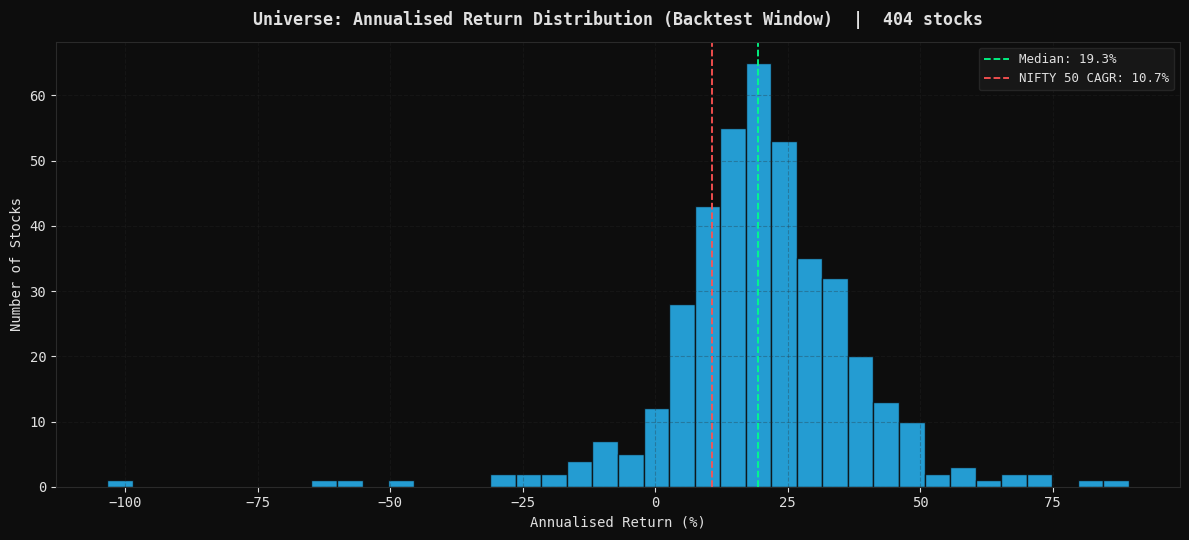

Saved -> .\output\01_universe_return_distribution.png


In [19]:
bt_returns = returns_simple[returns_simple.index >= BACKTEST_START]
ann_ret = bt_returns.mean() * ANN_FACTOR * 100
ann_vol = bt_returns.std()  * np.sqrt(ANN_FACTOR) * 100

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.hist(ann_ret.dropna(), bins=40, color=COLORS[0], alpha=0.85, edgecolor=DARK_BG)
ax.axvline(ann_ret.median(), color=ACCENT, linestyle='--', linewidth=1.3,
           label=f'Median: {ann_ret.median():.1f}%')
ax.axvline(bm_cagr, color=ACCENT2, linestyle='--', linewidth=1.3,
           label=f'NIFTY 50 CAGR: {bm_cagr:.1f}%')
ax.set_title(f'Universe: Annualised Return Distribution (Backtest Window)  |  {len(tickers_with_data)} stocks',
             fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_xlabel('Annualised Return (%)')
ax.set_ylabel('Number of Stocks')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '01_universe_return_distribution.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell 21 — Save All Outputs to data/

In [20]:
prices_clean.to_csv(os.path.join(DATA_DIR, 'raw_prices.csv'))
volumes_clean.to_csv(os.path.join(DATA_DIR, 'raw_volumes.csv'))
returns_simple.to_csv(os.path.join(DATA_DIR, 'daily_returns.csv'))
returns_log.to_csv(os.path.join(DATA_DIR, 'log_returns.csv'))
membership_panel.to_csv(os.path.join(DATA_DIR, 'amfi_membership_panel.csv'), index=False)
membership_matrix.to_csv(os.path.join(DATA_DIR, 'amfi_membership_matrix.csv'))

pd.Series(amfi_name_map, name='company').to_csv(os.path.join(DATA_DIR, 'ticker_company_map.csv'))

master_universe_df = pd.DataFrame({'ticker': tickers_with_data})
master_universe_df.to_csv(os.path.join(DATA_DIR, 'master_universe.csv'), index=False)

import json
with open(os.path.join(DATA_DIR, 'study_window.json'), 'w') as f:
    json.dump({
        'warmup_start':   WARMUP_START,
        'backtest_start': BACKTEST_START,
        'end_date':       END_DATE,
    }, f, indent=2)

print('Saved to data/:')
for f in ['raw_prices.csv', 'raw_volumes.csv', 'daily_returns.csv', 'log_returns.csv',
          'benchmark_nifty50.csv', 'amfi_membership_panel.csv', 'amfi_membership_matrix.csv',
          'ticker_company_map.csv', 'master_universe.csv', 'ticker_resolution_log.csv',
          'data_quality_report.csv', 'study_window.json']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 01 -- COMPLETE')
print('=' * 60)
print(f'  Study window       : {WARMUP_START} (warm-up) / {BACKTEST_START} (backtest) -> {END_DATE}')
print(f'  AMFI snapshots used: {len(snapshot_frames)}')
print(f'  Final universe      : {len(tickers_with_data)} tickers (ever Large/Mid Cap, usable data)')
print(f'  Trading days        : {prices_clean.shape[0]}')
print(f'  NIFTY 50 CAGR (bt)  : {bm_cagr:.2f}%')
print(f'  Universe median ret : {ann_ret.median():.2f}% ann. (backtest window)')
print()
print('  Charts in output/:')
for f in ['01_universe_composition_over_time.png', '01_universe_turnover.png',
          '01_benchmark_nifty50.png', '01_universe_return_distribution.png']:
    print(f'    {f}')
print()
print('  Next -> Notebook 02: Factor Research')


Saved to data/:
  raw_prices.csv
  raw_volumes.csv
  daily_returns.csv
  log_returns.csv
  benchmark_nifty50.csv
  amfi_membership_panel.csv
  amfi_membership_matrix.csv
  ticker_company_map.csv
  master_universe.csv
  ticker_resolution_log.csv
  data_quality_report.csv
  study_window.json

NOTEBOOK 01 -- COMPLETE
  Study window       : 2015-07-01 (warm-up) / 2018-07-01 (backtest) -> 2026-07-16
  AMFI snapshots used: 17
  Final universe      : 404 tickers (ever Large/Mid Cap, usable data)
  Trading days        : 2755
  NIFTY 50 CAGR (bt)  : 10.68%
  Universe median ret : 19.32% ann. (backtest window)

  Charts in output/:
    01_universe_composition_over_time.png
    01_universe_turnover.png
    01_benchmark_nifty50.png
    01_universe_return_distribution.png

  Next -> Notebook 02: Factor Research


---
## Notebook Summary

| Step | Action | Result |
|------|--------|--------|
| Cell 2 | Configure study window | Warm-up 2015-07-01, backtest 2018-07-01 -> latest |
| Cells 4–6 | AMFI catalogue + download all 17 snapshots | Long-format membership panel, 2018-06-30 -> latest |
| Cell 7 | Master universe + membership matrix | Union of all-time Large/Mid Cap tickers |
| Cells 8–9 | Universe evolution diagnostics | Composition & turnover charts |
| Cells 10–11 | NIFTY 50 benchmark | Downloaded, charted, saved |
| Cell 13 | **Corporate Action Registry** | Renames / mergers / delistings / unknowns classified explicitly |
| Cell 14 | **Download Plan** | Registry applied *before* download — merger/delisted pre-excluded |
| Cell 15 | Batch download + retry | Registry-resolved symbols, transient failures recovered |
| Cell 16 | **Resolution Log** | Every ticker gets an explicit status — nothing silently dropped |
| Cell 17 | Finalise price/volume panel | Only `SUCCESS` / `RENAMED` tickers carry forward |
| Cell 18 | **Data Quality Report** | Universe collapse fully documented, saved as CSV |
| Cells 19–20 | Returns + distribution diagnostic | Simple & log returns, cross-sectional return histogram |
| Cell 21 | Save all outputs | 11 files + 4 charts, Notebook 02 ready |

**Key methodological notes carried forward:**

1. The membership panel and matrix let Notebook 03 answer, independently at every rebalance date,
   *"what was the actual eligible Large+Mid Cap universe on this date, using only the AMFI snapshot
   that would genuinely have been available then?"* — this is what makes the backtest walk-forward
   in the truest sense, not just for prices, but for the universe definition itself.
2. The Corporate Action Registry + Resolution Log + Data Quality Report together mean every excluded
   stock has a recorded, auditable reason — `data/ticker_resolution_log.csv` and
   `data/data_quality_report.csv` are the definitive references if a later notebook (or a reviewer)
   asks "why isn't stock X in the universe?"
3. The registry is intentionally **not exhaustive** — tickers marked `UNKNOWN` are a known, disclosed
   gap, not a hidden one. Extend `CORPORATE_ACTION_REGISTRY` in Cell 13 if you confirm a resolution
   for any of them.
